# Metrics data analysis

**Inputs**:
`og_stats_d3_n8.csv` (762 orbits, $d=3$, $n\le8$), `og_stats_d5_n6.csv`
(49 orbits, $d=5$, $n\le6$) and `table_d2_n9.csv` (585 orbits, $d=2$,
$n\le9$).


## 0. Setup and data

Conventions: as in the paper and its data files.

In [1]:
# [d=2 update] d=2 is now a primary input (table_d2_n9.csv, paper pipeline at d=2, n<=9);
#              og_stats_d2_n8.csv is no longer loaded and the per-n class-count check extends to n=9.
import os, json
import numpy as np
import pandas as pd

for f in ("og_stats_d3_n8.csv", "og_stats_d5_n6.csv", "table_d2_n9.csv"):
    assert os.path.exists(f), f"missing primary input {f} (paper pipeline)"
for f in ("orbit_payloads.json",):
    assert os.path.exists(f), (f"missing derived input {f} — run Appendix A "
                               "(bottom of this notebook) once to create it")
os.makedirs("figures", exist_ok=True)
os.makedirs("out", exist_ok=True)

raw3 = pd.read_csv("og_stats_d3_n8.csv")
raw5 = pd.read_csv("og_stats_d5_n6.csv")
d2raw = pd.read_csv("table_d2_n9.csv")
PAYLOADS = json.load(open("orbit_payloads.json"))["panels"]

print(f"d=3 (primary): {len(raw3)} orbits, n = {raw3.n.min()}..{raw3.n.max()};  "
      f"per n: {raw3.groupby('n').size().to_dict()}")
print(f"d=5 (primary): {len(raw5)} orbits, n = {raw5.n.min()}..{raw5.n.max()};  "
      f"per n: {raw5.groupby('n').size().to_dict()}")
print(f"E_S known exactly for {(raw3.es_lo == raw3.es_up).sum()}/762 (d=3) "
      f"and {(raw5.es_lo == raw5.es_up).sum()}/49 (d=5) orbits")
print(f"sampled ASPL/diameter rows: d=3: {(~raw3.diameter_exactly_known).sum()}"
      f" (all n=8), d=5: {(~raw5.diameter_exactly_known).sum()}")

counts = {int(k): int(v) for k, v in d2raw.groupby('n').size().items()}
# known qubit classification: Hein et al. (n<=7), Cabello et al. (n=8),
# Danielsen & Parker / Adcock et al. (n=9: 440; 587 classes incl. n=1,2)
assert counts == {3: 1, 4: 2, 5: 4, 6: 11, 7: 26, 8: 101, 9: 440}, counts
print(f"\nd=2 (primary, paper pipeline at d=2): {len(d2raw)} orbits, "
      f"n = {d2raw.n.min()}..{d2raw.n.max()}; per-n counts {counts} match the "
      f"known qubit classification")
print(f"E_S known exactly for {(d2raw.es_lo == d2raw.es_up).sum()}/{len(d2raw)} "
      f"(d=2) orbits; sampled ASPL/diameter rows: "
      f"{(~d2raw.diameter_exactly_known).sum()}")
print(f"orbit payloads for the diagram figure: "
      f"{[p['title'] for p in PAYLOADS]}")


d=3 (primary): 762 orbits, n = 3..8;  per n: {3: 1, 4: 3, 5: 5, 6: 21, 7: 73, 8: 659}
d=5 (primary): 49 orbits, n = 3..6;  per n: {3: 1, 4: 3, 5: 7, 6: 38}
E_S known exactly for 578/762 (d=3) and 44/49 (d=5) orbits
sampled ASPL/diameter rows: d=3: 610 (all n=8), d=5: 38

d=2 (primary, paper pipeline at d=2): 585 orbits, n = 3..9; per-n counts {3: 1, 4: 2, 5: 4, 6: 11, 7: 26, 8: 101, 9: 440} match the known qubit classification
E_S known exactly for 404/585 (d=2) orbits; sampled ASPL/diameter rows: 0
orbit payloads for the diagram figure: ['$d=3$, GHZ$_4$ class ($|V|=10$)', '$d=3$, path$_4$ class ($|V|=37$)', '$d=5$, GHZ$_4$ class ($|V|=58$)']


## 1. Statistical validation of the correlation analysis

In [2]:
"""
Inference layer for the correlation re-analysis (Reviewer 2, point 1).

Conventions
-----------
* Family of tests: all C(9,2) = 36 unordered pairs of the nine metrics used
  in the manuscript, with transforms fixed per VARIABLE (not per pair):
      ln(N_L + 1)  for the self-loop count      (as already used in the paper)
      ln(D)        for the OG density           (spans several decades)
      identity     for everything else.
  Kendall's tau_b is invariant under monotone transforms, so the tau column
  is unaffected by this choice.
* Pearson r: two-sided p from the exact t reference distribution
  (scipy.stats.pearsonr), 95% CI via the Fisher z-transform,
  atanh(r) +/- z_{0.975}/sqrt(N-3).
* Kendall tau_b: two-sided p from the tie-corrected asymptotic normal
  approximation (scipy default for N > 33); 95% percentile bootstrap CI.
* Multiple comparisons: Bonferroni-adjusted p and Benjamini-Hochberg
  FDR-adjusted q, each within one family (one dataset, one coefficient).
* Strength criterion replacing the bare |r| > 0.8 threshold:
      DETECTED: q_BH <= 0.05
      STRONG:   DETECTED and the 95% Fisher CI lower bound of |r| >= 0.70
  (0.70 is the conventional strong-correlation threshold already cited in
  the manuscript; demanding the whole CI above it is what implicitly made
  the point-estimate cut 0.8 at N = 103.)
"""

import numpy as np
import pandas as pd
from scipy import stats

RNG = np.random.default_rng(20260825)

METRICS = ["chi_og", "lnNL", "chi_min", "lnD", "aspl",
           "diameter", "mindeg_g", "max_degree", "E_S"]

LABELS = {
    "chi_og": r"$\chi_{OG}$",
    "lnNL": r"$\ln(N_{\mathcal{L}}+1)$",
    "chi_min": r"$\chi_i$",
    "lnD": r"$\ln\mathcal{D}$",
    "aspl": r"$\langle d_{OG}\rangle$",
    "diameter": r"$d_{OG}^{\max}$",
    "mindeg_g": r"$\deg(g)_{\min}$",
    "max_degree": r"$\deg(OG)_{\max}$",
    "E_S": r"$E_S$",
}


def prepare(df):
    """Attach the fixed-transform analysis columns to an orbit-stats table."""
    s = df.copy()
    s["E_S"] = (s["es_lo"] + s["es_up"]) / 2          # midpoint convention
    s["lnNL"] = np.log(s["selfloops"] + 1)
    s["lnD"] = np.log(s["density"])
    return s


def fisher_ci(r, n, alpha=0.05):
    if n <= 3 or abs(r) >= 1:
        return (np.nan, np.nan)
    z = np.arctanh(r)
    h = stats.norm.ppf(1 - alpha / 2) / np.sqrt(n - 3)
    return (np.tanh(z - h), np.tanh(z + h))


def bh_adjust(p):
    """Benjamini-Hochberg adjusted q-values."""
    p = np.asarray(p, dtype=float)
    m = len(p)
    order = np.argsort(p)
    ranked = p[order] * m / (np.arange(m) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty(m)
    out[order] = np.minimum(ranked, 1.0)
    return out


def bonf_adjust(p):
    return np.minimum(np.asarray(p, dtype=float) * len(p), 1.0)


def kendall_boot_ci(x, y, B=5000, alpha=0.05, rng=None):
    rng = rng or RNG
    n = len(x)
    idx = rng.integers(0, n, size=(B, n))
    vals = np.empty(B)
    xa, ya = np.asarray(x), np.asarray(y)
    for b in range(B):
        i = idx[b]
        vals[b] = stats.kendalltau(xa[i], ya[i]).statistic
    return (np.nanquantile(vals, alpha / 2),
            np.nanquantile(vals, 1 - alpha / 2))


def pearson_boot_ci(x, y, B=5000, alpha=0.05, rng=None):
    rng = rng or RNG
    n = len(x)
    xa, ya = np.asarray(x, float), np.asarray(y, float)
    idx = rng.integers(0, n, size=(B, n))
    xs, ys = xa[idx], ya[idx]
    xs = xs - xs.mean(1, keepdims=True)
    ys = ys - ys.mean(1, keepdims=True)
    num = (xs * ys).sum(1)
    den = np.sqrt((xs ** 2).sum(1) * (ys ** 2).sum(1))
    vals = num / den
    return (np.nanquantile(vals, alpha / 2),
            np.nanquantile(vals, 1 - alpha / 2))


def perm_pvalue_pearson(x, y, B=100_000, rng=None):
    """Monte-Carlo permutation p for |r| (exchangeability null).

    Resolution floor is 1/(B+1): reported p of that size means 'no permuted
    replicate reached |r_obs|'."""
    rng = rng or RNG
    xa = np.asarray(x, float)
    ya = np.asarray(y, float)
    xa = (xa - xa.mean()) / xa.std()
    yc = ya - ya.mean()
    r_obs = abs(np.mean(xa * yc) / yc.std())
    hits = 0
    chunk = 2000
    done = 0
    while done < B:
        k = min(chunk, B - done)
        Y = np.tile(yc, (k, 1))
        Y = rng.permuted(Y, axis=1)
        rs = np.abs((xa * Y).mean(1) / yc.std())
        hits += int((rs >= r_obs - 1e-15).sum())
        done += k
    return (hits + 1) / (B + 1)


def corr_table(df, metrics=METRICS, boot_B=5000, rng=None):
    """All-pairs inference table for one prepared dataset."""
    rng = rng or RNG
    rows = []
    N = len(df)
    for i in range(len(metrics)):
        for j in range(i + 1, len(metrics)):
            a, b = metrics[i], metrics[j]
            x, y = df[a].values, df[b].values
            pr = stats.pearsonr(x, y)
            kt = stats.kendalltau(x, y)
            lo, hi = fisher_ci(pr.statistic, N)
            klo, khi = kendall_boot_ci(x, y, B=boot_B, rng=rng)
            rows.append(dict(x=a, y=b, N=N,
                             r=pr.statistic, p_r=pr.pvalue,
                             r_lo=lo, r_hi=hi,
                             tau=kt.statistic, p_tau=kt.pvalue,
                             tau_lo=klo, tau_hi=khi))
    t = pd.DataFrame(rows)
    t["p_r_bonf"] = bonf_adjust(t["p_r"])
    t["q_r_bh"] = bh_adjust(t["p_r"])
    t["p_tau_bonf"] = bonf_adjust(t["p_tau"])
    t["q_tau_bh"] = bh_adjust(t["p_tau"])
    t["abs_r_lo"] = np.where(t.r >= 0, t.r_lo, -t.r_hi)   # CI bound nearer 0
    t["detected"] = t.q_r_bh <= 0.05
    t["strong"] = t.detected & (t.abs_r_lo >= 0.70)
    return t


def partial_pearson(df, a, b, ctrl="n"):
    """First-order partial correlation r_{ab.ctrl}."""
    r_ab = stats.pearsonr(df[a], df[b]).statistic
    r_ac = stats.pearsonr(df[a], df[ctrl]).statistic
    r_bc = stats.pearsonr(df[b], df[ctrl]).statistic
    return ((r_ab - r_ac * r_bc)
            / np.sqrt((1 - r_ac ** 2) * (1 - r_bc ** 2)))


In [3]:
# [d=2 update] full d=2 dataset is now n<=9 ('d2_n9'); 'd2_n7'/'d2_n8' kept as
#              nested subsets for reference (matched-range look-ups), as before.
# reporting helpers -------------------------------------------------
d2 = prepare(d2raw)
d3 = prepare(raw3)
d5 = prepare(raw5)
DATASETS = {"d2_n7": d2[d2.n <= 7], "d2_n8": d2[d2.n <= 8], "d2_n9": d2,
            "d3_n7": d3[d3.n <= 7], "d3_n8": d3, "d5_n6": d5}

def get(tab, a, b):
    m = tab[((tab.x == a) & (tab.y == b)) | ((tab.x == b) & (tab.y == a))]
    return m.iloc[0]

def r_star(N, thr=0.70):
    from scipy.optimize import brentq
    return brentq(lambda r: fisher_ci(r, N)[0] - thr, 0.4, 0.999)

print("point estimate |r| needed for '95% CI entirely above 0.70':")
for key, s in DATASETS.items():
    print(f"  {key:6s} (N={len(s):3d}):  |r| >= {r_star(len(s)):.3f}")


point estimate |r| needed for '95% CI entirely above 0.70':
  d2_n7  (N= 44):  |r| >= 0.825
  d2_n8  (N=145):  |r| >= 0.775
  d2_n9  (N=585):  |r| >= 0.739
  d3_n7  (N=103):  |r| >= 0.787
  d3_n8  (N=762):  |r| >= 0.735
  d5_n6  (N= 49):  |r| >= 0.820


### 1.1 Full inference tables

One table per dataset ($36$ pairs each). `detected` = BH $q\le0.05$;
`strong` = detected **and** CI lower bound of $|r|\ge0.70$. The complete
tables are written to `out/corr_full_*.csv`; the strong pairs of the primary
$d=3$, $n\le8$ dataset are displayed below.

In [4]:
TABS = {}
for key, s in DATASETS.items():
    # per-dataset seeded generator -> bootstrap CIs independent of run order
    rng = np.random.default_rng(int.from_bytes(key.encode(), "little") % 2**32)
    TABS[key] = corr_table(s, boot_B=2000, rng=rng)
    TABS[key].round(6).to_csv(f"out/corr_full_{key}.csv", index=False)
    t = TABS[key]
    print(f"{key:6s} N={len(s):3d}: detected {int(t.detected.sum()):2d}/36, "
          f"strong {int(t.strong.sum()):2d}/36  "
          f"(Bonferroni p<=0.05 agrees with BH on all strong pairs: "
          f"{bool((t[t.strong].p_r_bonf <= 0.05).all())})")

show = TABS['d3_n8'][TABS['d3_n8'].strong] \
        .sort_values('r', key=abs, ascending=False) \
        [['x','y','N','r','r_lo','r_hi','p_r','q_r_bh','p_r_bonf',
          'tau','tau_lo','tau_hi','q_tau_bh']]
show.style.format({c: '{:+.3f}' for c in
                   ('r','r_lo','r_hi','tau','tau_lo','tau_hi')} |
                  {c: '{:.2e}' for c in
                   ('p_r','q_r_bh','p_r_bonf','q_tau_bh')})

d2_n7  N= 44: detected 28/36, strong 10/36  (Bonferroni p<=0.05 agrees with BH on all strong pairs: True)
d2_n8  N=145: detected 33/36, strong 11/36  (Bonferroni p<=0.05 agrees with BH on all strong pairs: True)
d2_n9  N=585: detected 34/36, strong 13/36  (Bonferroni p<=0.05 agrees with BH on all strong pairs: True)
d3_n7  N=103: detected 28/36, strong 15/36  (Bonferroni p<=0.05 agrees with BH on all strong pairs: True)
d3_n8  N=762: detected 30/36, strong 15/36  (Bonferroni p<=0.05 agrees with BH on all strong pairs: True)
d5_n6  N= 49: detected 20/36, strong  9/36  (Bonferroni p<=0.05 agrees with BH on all strong pairs: True)


,x,y,N,r,r_lo,r_hi,p_r,q_r_bh,p_r_bonf,tau,tau_lo,tau_hi,q_tau_bh
21,lnD,aspl,762,-0.988,-0.990,-0.986,0.00e+00,0.00e+00,0.00e+00,-0.877,-0.885,-0.869,9.16e-286
22,lnD,diameter,762,-0.939,-0.947,-0.930,0.00e+00,0.00e+00,0.00e+00,-0.822,-0.836,-0.806,5.99e-207
26,aspl,diameter,762,+0.938,+0.929,+0.946,0.00e+00,0.00e+00,0.00e+00,+0.814,+0.796,+0.830,1.43e-203
2,chi_og,lnD,762,-0.882,-0.897,-0.865,1.29e-250,1.16e-249,4.63e-249,-0.719,-0.742,-0.695,1.03e-162
6,chi_og,max_degree,762,+0.848,+0.827,+0.867,1.02e-211,7.32e-211,3.66e-210,+0.679,+0.648,+0.707,1.96e-109
4,chi_og,diameter,762,+0.833,+0.809,+0.853,3.09e-197,1.86e-196,1.11e-195,+0.698,+0.665,+0.729,1.27e-126
3,chi_og,aspl,762,+0.823,+0.799,+0.845,3.52e-189,1.81e-188,1.27e-187,+0.629,+0.599,+0.660,3.29e-125
35,max_degree,E_S,762,+0.822,+0.797,+0.844,5.65e-188,2.54e-187,2.03e-186,+0.687,+0.654,+0.719,4.81e-103
7,chi_og,E_S,762,+0.809,+0.783,+0.832,1.39e-177,5.58e-177,5.02e-176,+0.669,+0.634,+0.699,1.04e-109
25,lnD,E_S,762,-0.798,-0.823,-0.771,1.93e-169,6.95e-169,6.95e-168,-0.622,-0.655,-0.590,2.14e-112


### Published Table 3 ($d=3$, $n\le7$)

For each of the 15 published pairs we recompute $r$ and $\tau$ on the
$n\le7$ data with the *published* transform, then give the fixed-transform
value with its CI and corrected significance, and the verdict under the new
criterion. Two technical notes explain the small recomputation offsets:
(i) the current data re-run upgraded some $n=7$ heuristic
diameters/ASPL to exact values and re-ran the greedy colouring, shifting
$\chi_{OG}$-pairs by $\lesssim0.03$; (ii) one published row is mislabelled:
"$\mathcal D$ vs $\langle d_{OG}\rangle$, $r=-0.99$" reproduces only with
$\ln\mathcal D$ ($r=-0.989$; raw $\mathcal D$ gives $-0.68$). The Kendall
values, which are transform-invariant, match throughout — confirming it is a
labelling slip, not a data problem.

In [5]:
s7 = DATASETS['d3_n7'].copy()
s7['lndegOG'] = np.log(s7.max_degree)
s7['lndmax'] = np.log(s7.diameter)
s7['lnaspl'] = np.log(s7.aspl)
s7['D'] = s7.density
# (label, published transform pair, r_pub, tau_pub, fixed-family pair)
PUB = [
 ("E_S vs chi_OG",        ('E_S','chi_og'),      0.84, 0.74, ('E_S','chi_og')),
 ("E_S vs ln D",          ('E_S','lnD'),        -0.82,-0.70, ('E_S','lnD')),
 ("E_S vs <d_OG>",        ('E_S','aspl'),        0.81, 0.67, ('E_S','aspl')),
 ("E_S vs d_OG^max",      ('E_S','diameter'),    0.81, 0.72, ('E_S','diameter')),
 ("E_S vs deg(OG)max",    ('E_S','max_degree'),  0.87, 0.72, ('E_S','max_degree')),
 ("deg(OG)max vs chi_OG", ('max_degree','chi_og'),0.91,0.81, ('chi_og','max_degree')),
 ("ln deg(OG)max vs D",   ('lndegOG','D'),      -0.92,-0.76, ('lnD','max_degree')),
 ("deg(OG)max vs <d_OG>", ('max_degree','aspl'), 0.85, 0.71, ('aspl','max_degree')),
 ("deg(OG)max vs d_OG^max",('max_degree','diameter'),0.85,0.74,('diameter','max_degree')),
 ("<d_OG> vs d_OG^max",   ('aspl','diameter'),   0.94, 0.84, ('aspl','diameter')),
 ("ln D vs d_OG^max",     ('lnD','diameter'),   -0.93,-0.84, ('lnD','diameter')),
 ("D vs <d_OG>  [mislabelled: ln D]", ('D','aspl'), -0.99,-0.90, ('lnD','aspl')),
 ("chi_OG vs ln d_OG^max",('chi_og','lndmax'),   0.85, 0.76, ('chi_og','diameter')),
 ("chi_OG vs ln <d_OG>",  ('chi_og','lnaspl'),   0.88, 0.69, ('chi_og','aspl')),
 ("chi_OG vs ln D",       ('chi_og','lnD'),     -0.92,-0.80, ('chi_og','lnD')),
]
from scipy import stats as sps
audit = []
t7 = TABS['d3_n7']
for label, (a, b), rp, tp, fixed in PUB:
    r_now = sps.pearsonr(s7[a], s7[b]).statistic
    tau_now = sps.kendalltau(s7[a], s7[b]).statistic
    row = get(t7, *fixed)
    audit.append(dict(pair=label, r_published=rp, r_recomputed=round(r_now, 3),
                      tau_published=tp, tau_recomputed=round(tau_now, 3),
                      r_fixed_transform=round(row.r, 3),
                      CI=f"[{row.r_lo:+.3f}, {row.r_hi:+.3f}]",
                      p=f"{row.p_r:.1e}", q_BH=f"{row.q_r_bh:.1e}",
                      detected=bool(row.detected), strong=bool(row.strong)))
audit = pd.DataFrame(audit)
n_surv = int(audit.strong.sum())
print(f"VERDICT: {n_surv}/15 published pairs survive the corrected criterion "
      f"on the n<=7 audit data; on the extended n<=8 data the strong set is "
      f"the same 15 pairs (Section 1.1).")
audit

VERDICT: 15/15 published pairs survive the corrected criterion on the n<=7 audit data; on the extended n<=8 data the strong set is the same 15 pairs (Section 1.1).


,pair,r_published,r_recomputed,tau_published,tau_recomputed,r_fixed_transform,CI,p,q_BH,detected,strong
0,E_S vs chi_OG,0.84,0.868,0.74,0.770,0.868,"[+0.811, +0.909]",1.7e-32,7.5e-32,True,True
1,E_S vs ln D,-0.82,-0.819,-0.70,-0.701,-0.819,"[-0.874, -0.744]",3.8e-26,1.1e-25,True,True
2,E_S vs <d_OG>,0.81,0.805,0.67,0.665,0.805,"[+0.724, +0.864]",1.3e-24,3.1e-24,True,True
3,E_S vs d_OG^max,0.81,0.815,0.72,0.732,0.815,"[+0.738, +0.871]",1.1e-25,2.8e-25,True,True
4,E_S vs deg(OG)max,0.87,0.865,0.72,0.716,0.865,"[+0.806, +0.907]",5.5e-32,2.2e-31,True,True
5,deg(OG)max vs chi_OG,0.91,0.920,0.81,0.831,0.920,"[+0.883, +0.945]",9.3e-43,8.4e-42,True,True
6,ln deg(OG)max vs D,-0.92,-0.919,-0.76,-0.763,-0.850,"[-0.896, -0.786]",7.2e-30,2.3e-29,True,True
7,deg(OG)max vs <d_OG>,0.85,0.850,0.71,0.708,0.850,"[+0.786, +0.896]",6.4e-30,2.3e-29,True,True
8,deg(OG)max vs d_OG^max,0.85,0.845,0.74,0.736,0.845,"[+0.779, +0.893]",3.2e-29,9.5e-29,True,True
9,<d_OG> vs d_OG^max,0.94,0.941,0.84,0.837,0.941,"[+0.914, +0.960]",3.0e-49,5.3e-48,True,True


### 1.3 Permutation check of the parametric p-values

Monte-Carlo permutation tests ($B=10^5$) under the exchangeability null for
the five $E_S$ pairs on the primary dataset. The permutation $p$ can resolve
at best $1/(B+1)\approx10^{-5}$; hitting that floor for every pair confirms
the parametric conclusions without distributional assumptions.

In [6]:
for a, b in [('E_S','chi_og'), ('E_S','lnD'), ('E_S','aspl'),
             ('E_S','diameter'), ('E_S','max_degree')]:
    p = perm_pvalue_pearson(d3[a], d3[b], B=100_000,
                            rng=np.random.default_rng(1))
    print(f"  {a} ~ {b:11s}: permutation p = {p:.1e}  (floor = 1.0e-05)")

  E_S ~ chi_og     : permutation p = 1.0e-05  (floor = 1.0e-05)
  E_S ~ lnD        : permutation p = 1.0e-05  (floor = 1.0e-05)
  E_S ~ aspl       : permutation p = 1.0e-05  (floor = 1.0e-05)
  E_S ~ diameter   : permutation p = 1.0e-05  (floor = 1.0e-05)
  E_S ~ max_degree : permutation p = 1.0e-05  (floor = 1.0e-05)


### 1.4 Robustness checks

In [8]:
# [d=2 update] robustness loops use the full d=2 dataset key 'd2_n9' instead of 'd2_n8'.
ES_PAIRS = [('E_S','chi_og'), ('E_S','lnD'), ('E_S','aspl'),
            ('E_S','diameter'), ('E_S','max_degree')]
from scipy import stats as sps
print("1) midpoint sensitivity: r on all orbits -> r on exactly-known only")
for key in ['d3_n7', 'd3_n8', 'd5_n6', 'd2_n9']:
    s = DATASETS[key]
    sx = s[s.es_lo == s.es_up]
    d = ", ".join(f"{b}: {sps.pearsonr(s[a],s[b]).statistic:+.2f}->"
                  f"{sps.pearsonr(sx[a],sx[b]).statistic:+.2f}"
                  for a, b in ES_PAIRS)
    print(f"   {key} (N {len(s)}->{len(sx)}): {d}")

print("\n2) partial correlations controlling for n:")
for key in ['d3_n8', 'd5_n6', 'd2_n9']:
    s = DATASETS[key]
    d = ", ".join(f"{b}: {sps.pearsonr(s[a],s[b]).statistic:+.2f}->"
                  f"{partial_pearson(s,a,b,'n'):+.2f}" for a, b in ES_PAIRS)
    print(f"   {key}: {d}")

se, var = 0.006, d3.aspl.var()
print(f"\n3) sampled-ASPL attenuation factor: "
      f"{var/(var + se**2):.6f} (i.e. bias < 2e-5 on r)")


1) midpoint sensitivity: r on all orbits -> r on exactly-known only
   d3_n7 (N 103->76): chi_og: +0.87->+0.81, lnD: -0.82->-0.76, aspl: +0.80->+0.76, diameter: +0.82->+0.76, max_degree: +0.86->+0.85
   d3_n8 (N 762->578): chi_og: +0.81->+0.78, lnD: -0.80->-0.77, aspl: +0.76->+0.76, diameter: +0.80->+0.78, max_degree: +0.82->+0.85
   d5_n6 (N 49->44): chi_og: +0.83->+0.83, lnD: -0.85->-0.85, aspl: +0.84->+0.85, diameter: +0.85->+0.86, max_degree: +0.77->+0.79
   d2_n9 (N 585->404): chi_og: +0.75->+0.71, lnD: -0.70->-0.70, aspl: +0.70->+0.72, diameter: +0.76->+0.77, max_degree: +0.82->+0.76

2) partial correlations controlling for n:
   d3_n8: chi_og: +0.81->+0.72, lnD: -0.80->-0.70, aspl: +0.76->+0.65, diameter: +0.80->+0.69, max_degree: +0.82->+0.71
   d5_n6: chi_og: +0.83->+0.71, lnD: -0.85->-0.75, aspl: +0.84->+0.73, diameter: +0.85->+0.75, max_degree: +0.77->+0.62
   d2_n9: chi_og: +0.75->+0.65, lnD: -0.70->-0.59, aspl: +0.70->+0.58, diameter: +0.76->+0.67, max_degree: +0.82->+0.75

## 2.  Data plotting

In [9]:
# [d=2 update] only the dataset label map DNAME changed (d2_n8 -> d2_n9, legend 'n<=9');
#              all figure code is unchanged.
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy import stats


C_D = {2: "#0072B2", 3: "#D55E00", 5: "#009E73"}      # fixed order, by entity
GREY = "#4d4d4d"

mpl.rcParams.update({
    "font.size": 8, "axes.labelsize": 8.5, "axes.titlesize": 9,
    "xtick.labelsize": 7.5, "ytick.labelsize": 7.5, "legend.fontsize": 7.5,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "figure.dpi": 110, "savefig.bbox": "tight",
})

MET_ORDER = ["E_S", "chi_og", "max_degree", "lnD", "aspl",
             "diameter", "lnNL", "chi_min", "mindeg_g"]
MET_LABEL = {
    "E_S": r"$E_S$",
    "chi_og": r"$\chi_{OG}$",
    "max_degree": r"$\mathrm{deg}(OG)_{\mathrm{max}}$",
    "lnD": r"$\ln\mathcal{D}$",
    "aspl": r"$\langle d_{OG}\rangle$",
    "diameter": r"$d_{OG}^{\mathrm{max}}$",
    "lnNL": r"$\ln(N_{\mathcal{L}}{+}1)$",
    "chi_min": r"$\chi_i$",
    "mindeg_g": r"$\mathrm{deg}(g)_{\mathrm{min}}$",
}
DNAME = {"d2_n9": (2, r"$d=2$, $n\leq 9$"), "d3_n8": (3, r"$d=3$, $n\leq 8$"),
         "d5_n6": (5, r"$d=5$, $n\leq 6$")}


def save(fig, stem):
    for ext in ("pdf", "svg", "png"):
        fig.savefig(f"figures/{stem}.{ext}",
                    dpi=300 if ext == "png" else None)
    from IPython.display import display
    display(fig)
    plt.close(fig)
    print("exported", ", ".join(f"figures/{stem}.{e}" for e in
                                ("pdf", "svg", "png")))


# ------------------------------------------------------ Fig 1: distributions

def _is_discrete(dsets, col, max_uniques=15):
    vals = np.concatenate([d[col].values for d in dsets.values()])
    uniq = np.unique(vals)
    return len(uniq) <= max_uniques and np.allclose(uniq, np.round(uniq))


def _plot_dist_panel(ax, dsets, col, xlabel, log=False):
    data = {key: (np.log(s[col].values) if log else s[col].values)
            for key, s in dsets.items()}
    all_vals = np.concatenate(list(data.values()))

    if _is_discrete(dsets, col) and not log:
        vals = sorted(set(all_vals))
        w = 0.8 / len(dsets)
        for k, (key, arr) in enumerate(data.items()):
            d, lab = DNAME[key]
            frac = [np.mean(arr == v) for v in vals]
            ax.bar(np.array(vals) + (k - (len(dsets) - 1) / 2) * w, frac,
                   width=w, color=C_D[d], edgecolor="white",
                   linewidth=0.4, label=lab)
        ax.set_xticks(vals)
        ax.set_xticklabels([f"{v:g}" for v in vals])
    else:
        bins = np.histogram_bin_edges(all_vals, bins=25)
        for key, arr in data.items():
            d, lab = DNAME[key]
            ax.hist(arr, bins=bins, weights=np.full(len(arr), 1 / len(arr)),
                    histtype="step", lw=1.4, color=C_D[d], label=lab)

    ax.set_xlabel(xlabel)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="0.9", lw=0.5)


def fig_distributions(dsets, metrics=MET_ORDER):
    n = len(metrics)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.0, 2.4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, m in zip(axes, metrics):
        # 'lnD' is stored as raw 'density' in your dataframes, needs logging
        col = "density" if m == "lnD" else m
        _plot_dist_panel(ax, dsets, col, MET_LABEL[m], log=(m == "lnD"))

    for ax in axes[::ncols]:
        ax.set_ylabel("fraction of orbits")
    for ax in axes[n:]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, loc="upper center",
               ncol=len(dsets), bbox_to_anchor=(0.5, 1.04))

    for ax, lab in zip(axes[:n], "abcdefghi"):
        ax.text(-0.16, 1.05, f"({lab})", transform=ax.transAxes,
                fontsize=9, fontweight="bold")

    fig.tight_layout(w_pad=2.0, h_pad=2.2)
    save(fig, "fig_distributions")


# ------------------------------------------------------- Fig 2: heatmaps

def fig_heatmaps(tabs):
    fig, axes = plt.subplots(1, 3, figsize=(7.05, 2.75))
    cmap = plt.get_cmap("RdBu_r")
    norm = mpl.colors.Normalize(-1, 1)
    m = len(MET_ORDER)
    for ax, key in zip(axes, DNAME):
        t = tabs[key]
        d, lab = DNAME[key]
        R = np.full((m, m), np.nan)
        det = np.zeros((m, m), bool)
        stg = np.zeros((m, m), bool)
        for _, row in t.iterrows():
            if row.x in MET_ORDER and row.y in MET_ORDER:
                i, j = MET_ORDER.index(row.x), MET_ORDER.index(row.y)
                i, j = max(i, j), min(i, j)          # lower triangle
                R[i, j] = row.r
                det[i, j] = row.detected
                stg[i, j] = row.strong
        for i in range(m):
            for j in range(i):
                x, y = j, i
                if det[i, j]:
                    ax.add_patch(Rectangle((x, y), 1, 1, lw=0.6, edgecolor="white",
                                 facecolor=cmap(norm(R[i, j]))))
                    dark = abs(R[i, j]) > 0.62
                    ax.text(x + .5, y + .5, f"{R[i, j]:+.2f}".replace("0.", "."),
                            ha="center", va="center", fontsize=5.3,
                            color="white" if dark else "#222222",
                            fontweight="bold" if stg[i, j] else "normal")
                else:
                    ax.add_patch(Rectangle((x, y), 1, 1, lw=0, facecolor="0.93",
                                           hatch="///", edgecolor="0.8"))
                if stg[i, j]:
                    ax.add_patch(Rectangle((x + 0.055, y + 0.055), 0.89, 0.89,
                                 fill=False, edgecolor="#111111", lw=0.9))
        ax.set_xlim(0, m - 1)
        ax.set_ylim(m, 1)
        ax.set_xticks(np.arange(m - 1) + .5)
        ax.set_xticklabels([MET_LABEL[k] for k in MET_ORDER[:-1]],
                           rotation=90)
        ax.set_yticks(np.arange(1, m) + .5)
        ax.set_yticklabels([MET_LABEL[k] for k in MET_ORDER[1:]])
        ax.tick_params(length=0)
        for s in ax.spines.values():
            s.set_visible(False)
        N = t.N.iloc[0]
        ax.set_title(f"{lab}   ($N={N}$ orbits)", pad=4)
        ax.set_aspect("equal")
    cax = fig.add_axes([0.955, 0.24, 0.012, 0.55])
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm, cmap), cax=cax)
    cb.set_label(r"Pearson $r$", size=7.5)
    cb.ax.tick_params(labelsize=6.5, width=0.5)
    cb.outline.set_linewidth(0.5)
    fig.subplots_adjust(left=0.075, right=0.94, top=0.9, bottom=0.24,
                        wspace=0.55)
    save(fig, "fig_corr_heatmaps")


# ------------------------------------------------------ Fig 3: scatters

import string


def _fit_ols_band(x, y, xg):
    X = np.column_stack([np.ones_like(x), x])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    dof = len(x) - 2
    s2 = ((y - yhat) ** 2).sum() / dof
    Xg = np.column_stack([np.ones_like(xg), xg])
    cov = s2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.einsum("ij,jk,ik->i", Xg, cov, Xg))
    tq = stats.t.ppf(0.975, dof)
    yg = Xg @ beta
    return yg, yg - tq * se, yg + tq * se


def _plot_scatter_panel(ax, data, tab, xv, yv, color, ylim=None):
    x, y = data[xv].values, data[yv].values
    # multiplicity-scaled markers (many orbits share discrete values)
    pts = pd.DataFrame({"x": np.round(x, 6), "y": y}) \
            .groupby(["x", "y"]).size().reset_index(name="c")
    ax.scatter(pts.x, pts.y, s=4 + 10 * np.sqrt(pts.c), lw=0.4,
               facecolor=color, edgecolor="white", alpha=0.85, zorder=3)

    xg = np.linspace(x.min(), x.max(), 120)
    yg, lo, hi = _fit_ols_band(x, y, xg)
    ax.plot(xg, yg, color=GREY, lw=1.2, zorder=4)
    ax.fill_between(xg, lo, hi, color=GREY, alpha=0.22, lw=0, zorder=2)

    row = tab[((tab.x == xv) & (tab.y == yv)) |
              ((tab.x == yv) & (tab.y == xv))].iloc[0]
    if ylim is not None:
        ax.set_ylim(*ylim)

    q_exp = (max(-300, int(np.ceil(np.log10(row.q_r_bh))))
             if row.q_r_bh > 0 else -300)
    ax.set_title(
        (f"$r={row.r:+.2f}$  CI$\\,[{row.r_lo:+.2f},{row.r_hi:+.2f}]$\n"
         f"$q_{{\\rm BH}}<10^{{{q_exp}}}$  $\\tau_b={row.tau:+.2f}$"),
        fontsize=6.2, pad=4, linespacing=1.4)

    ax.set_xlabel(MET_LABEL[xv])
    ax.set_axisbelow(True)
    ax.grid(color="0.92", lw=0.5)


def fig_scatters(data, tab, d, pairs=None, ncols=4, ylim=None):
    if pairs is None:
        pairs = [("chi_og", "E_S"), ("max_degree", "E_S"),
                 ("lnD", "E_S"), ("diameter", "E_S")]
    n = len(pairs)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.05, 2.05 * nrows),
                             sharey=True)
    axes = np.atleast_1d(axes).ravel()
    color = C_D[d]

    for ax, (xv, yv) in zip(axes, pairs):
        _plot_scatter_panel(ax, data, tab, xv, yv, color, ylim=ylim)

    for ax in axes[::ncols]:
        ax.set_ylabel(rf"$E_S$  (units of $\log_{d}$)")
    for ax in axes[n:]:
        ax.axis("off")

    labels = string.ascii_lowercase[:n]
    for ax, lab in zip(axes[:n], labels):
        ax.text(0.86, 0.06, f"({lab})", transform=ax.transAxes,
               fontsize=8.5, fontweight="bold")

    fig.tight_layout(w_pad=1.2, h_pad=1.6)
    save(fig, f"fig_scatter_es_d{d}")

# -------------------------------------------------- Fig 4: orbit networks

def draw_orbit(ax, pay, title, shades, seed=11):
    import networkx as nx
    V = len(pay["members"])
    G = nx.Graph()
    G.add_nodes_from(range(V))
    etypes = {}
    for u, v, t in pay["edges"]:
        G.add_edge(u, v)
        etypes[(u, v)] = "both" if len(t) > 1 else t[0]
    pos = nx.kamada_kawai_layout(G)
    ec = {"LC": "#88add2", "LS": "#E69F00", "both": "#555555"}
    for (u, v), t in etypes.items():
        x = [pos[u][0], pos[v][0]]
        y = [pos[u][1], pos[v][1]]
        ax.plot(x, y, color=ec[t], lw=0.55 if V > 40 else 0.8,
                alpha=0.75, zorder=1,
                linestyle=(0, (2.5, 1.2)) if t == "LS" else "-")
    counts = pay["member_edge_counts"]
    uniq = sorted(set(counts))
    rep_id = pay["members"].index(pay["rep"])
    xs = [pos[v][0] for v in range(V)]
    ys = [pos[v][1] for v in range(V)]
    size = 46 if V <= 12 else (26 if V <= 40 else 17)
    ax.scatter(xs, ys, s=size, c=[shades[c] for c in counts],
               edgecolor="white", lw=0.6, zorder=3)
    ax.scatter([pos[rep_id][0]], [pos[rep_id][1]], s=size * 2.6, marker="o",
               facecolor="none", edgecolor="#111111", lw=1.0, zorder=4)
    ax.set_title(title, pad=3, fontsize=8)
    ax.set_aspect("equal")
    ax.axis("off")
    return uniq, shades


def fig_orbits(payload_sets):
    fig, axes = plt.subplots(1, 3, figsize=(7.05, 2.7))
    all_e = sorted({c for pay, _t in payload_sets
                    for c in pay["member_edge_counts"]})
    cmap = plt.get_cmap("viridis")
    shades = {e: cmap(0.12 + 0.75 * k / max(1, len(all_e) - 1))
              for k, e in enumerate(all_e)}
    for ax, (pay, title) in zip(axes, payload_sets):
        draw_orbit(ax, pay, title, shades)
    from matplotlib.lines import Line2D
    handles = [
        Line2D([], [], color="#88add2", lw=1.2, label="local complementation"),
        Line2D([], [], color="#E69F00", lw=1.2, linestyle=(0, (2.5, 1.2)),
               label="local scaling"),
        Line2D([], [], color="#555555", lw=1.2, label="both"),
        Line2D([], [], marker="o", color="none", markerfacecolor="none",
               markeredgecolor="#111111", markersize=7,
               label="representative"),
    ]
    for e in all_e:
        handles.append(Line2D([], [], marker="o", color="none",
                              markerfacecolor=shades[e],
                              markeredgecolor="white", markersize=6,
                              label=f"$|e|={e}$"))
    fig.legend(handles=handles, loc="lower center", ncol=len(handles),
               frameon=False, fontsize=6.6, columnspacing=1.1,
               handletextpad=0.5, bbox_to_anchor=(0.5, -0.04))
    for a, lab in zip(axes, "abc"):
        a.text(0.02, 0.97, f"({lab})", transform=a.transAxes,
               fontsize=8.5, fontweight="bold")
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save(fig, "fig_orbit_networks")

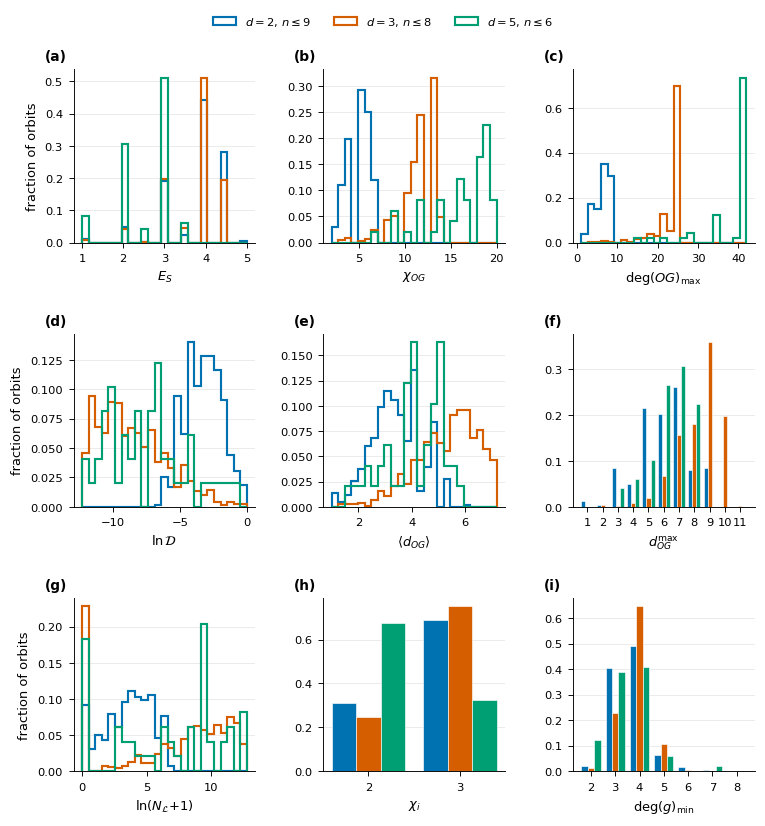

exported figures/fig_distributions.pdf, figures/fig_distributions.svg, figures/fig_distributions.png


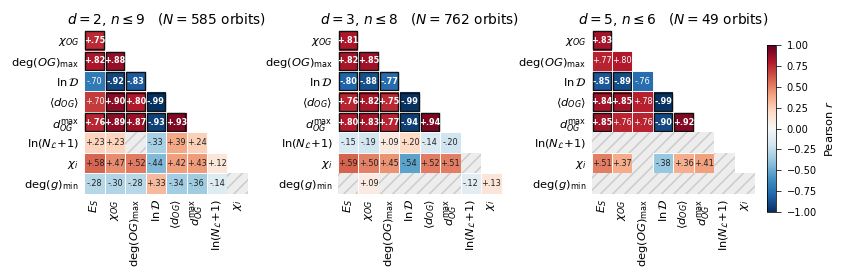

exported figures/fig_corr_heatmaps.pdf, figures/fig_corr_heatmaps.svg, figures/fig_corr_heatmaps.png


In [10]:
# [d=2 update] figure datasets use the full d=2 dataset key 'd2_n9' (d=2 panels of Fig. 1/2 change).
DSETS_FIG = {"d2_n9": d2, "d3_n8": d3, "d5_n6": d5}

# DSETS_FIG = {"d3_n8": d3, "d5_n6": d5}
# figure 1
fig_distributions(DSETS_FIG)
# figure 2
fig_heatmaps({k: TABS[k] for k in DSETS_FIG})


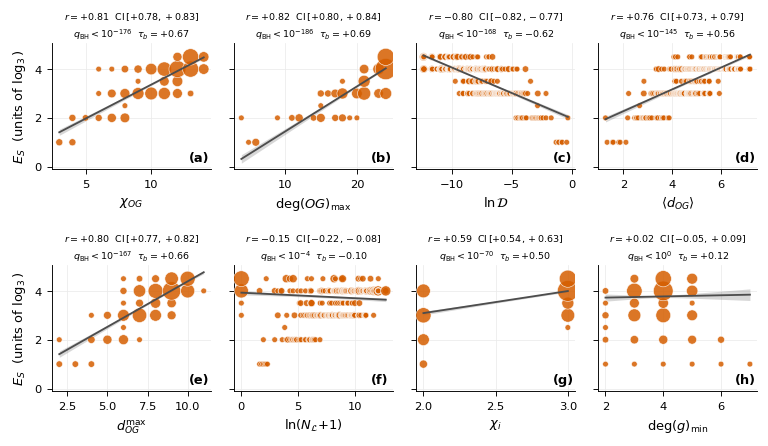

exported figures/fig_scatter_es_d3.pdf, figures/fig_scatter_es_d3.svg, figures/fig_scatter_es_d3.png


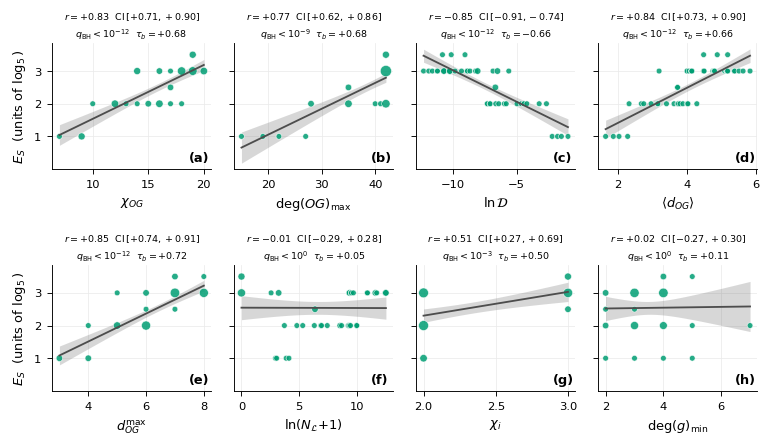

exported figures/fig_scatter_es_d5.pdf, figures/fig_scatter_es_d5.svg, figures/fig_scatter_es_d5.png


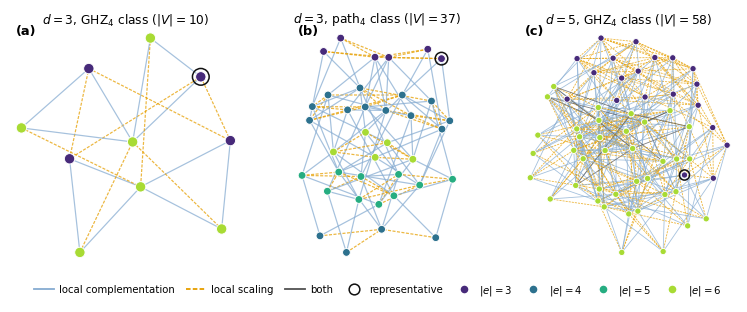

exported figures/fig_orbit_networks.pdf, figures/fig_orbit_networks.svg, figures/fig_orbit_networks.png


In [11]:
# # fig_scatters(d3, TABS['d3_n8'])
# fig_scatters(d3, TABS["d3_n8"], d=3)
# fig_scatters(d5, TABS["d5_n6"], d=5)
pairs_all = [(m, "E_S") for m in MET_ORDER if m != "E_S"]

fig_scatters(d3, TABS["d3_n8"], d=3, pairs=pairs_all, ncols=4)
fig_scatters(d5, TABS["d5_n6"], d=5, pairs=pairs_all, ncols=4)

# orbit network diagrams from the shipped payloads (provenance: Appendix A)
fig_orbits([(p["payload"], p["title"]) for p in PAYLOADS])

### Summary statistics of the metrics

Descriptive statistics per used metric: standard deviation and variance, biased skewness, smallest mode when multimodal, range = max − min, and interval-valued $E_S$ at the midpoint of its bounds.

In [12]:
# [d=2 update] d=2 summary table now built from the n<=9 dataset ('d2_n9', caption N=585);
#              output file renamed accordingly (out/table_summary_stats_d2_n9.tex).
# --- summary-statistics tables (updates the paper's Table `tab:summary_statistics_obs`) ---
from scipy import stats as sps

SUMM_ROWS = [("chi_og",     r"$\chi_{OG}$",                     2),
             ("selfloops",  r"$N_{\mathcal{L}}$",               2),
             ("chi_min",    r"$\chi_i$",                        2),
             ("density",    r"$\mathcal{D}$",                   4),
             ("aspl",       r"$\langle d_{OG} \rangle$",        2),
             ("diameter",   r"$d_{OG}^{\text{max}}$",           2),
             ("mindeg_g",   r"$\deg(g)_{\text{min}}$",          2),
             ("max_degree", r"$\text{deg}(OG)_{\text{max}}$",   2),
             ("E_S",        r"$E_S$",                           2)]
SUMM_CAPTION = {
 "d3_n8": (r"Summary of the statistical properties of the considered metrics "
           r"for the $d=3$, $n\leq8$ dataset ($N=762$ orbits), including the "
           r"mean, standard deviation, variance, median, mode, range, and "
           r"skewness. Population (biased) estimators are used, as in the "
           r"previous version of the table; orbits with interval-valued $E_S$ "
           r"enter at the midpoint of their bounds.",
           "tab:summary_statistics_obs"),
 "d5_n6": (r"As Table~\ref{tab:summary_statistics_obs}, for the $d=5$, "
           r"$n\leq6$ dataset ($N=49$ orbits).",
           "tab:summary_statistics_obs_d5"),
 "d2_n9": (r"As Table~\ref{tab:summary_statistics_obs}, for the qubit "
           r"($d=2$, $n\leq9$) dataset ($N=585$ orbits).",
           "tab:summary_statistics_obs_d2"),
}

def fmt_stat(v, dec):
    """Fixed-point with `dec` decimals; scientific LaTeX for tiny D cells."""
    if dec == 4 and v != 0 and abs(v) < 5e-5:
        e = int(np.floor(np.log10(abs(v))))
        return rf"${v / 10**e:.2f}\times10^{{{e}}}$"
    return f"${v:.{dec}f}$"

def summary_stats(s):
    """Descriptive statistics with the conventions of the published Table 2:
    population (ddof=0) SD/variance, biased skewness, smallest mode when
    multimodal, range = max - min; E_S at the bound midpoint."""
    rows = []
    for col, lab, dec in SUMM_ROWS:
        x = s[col]
        rows.append({"metric": lab, "Mean": x.mean(),
                     "Standard Deviation": x.std(ddof=0),
                     "Variance": x.var(ddof=0), "Median": x.median(),
                     "Mode": x.mode().iloc[0], "Range": x.max() - x.min(),
                     "Skewness": sps.skew(x, bias=True), "_dec": dec})
    return pd.DataFrame(rows)

def emit_summary_table(key):
    caption, label = SUMM_CAPTION[key]
    t = summary_stats(DATASETS[key])
    body = []
    for _, r in t.iterrows():
        d = int(r["_dec"])
        cells = " & ".join(fmt_stat(r[c], d) for c in
                           ("Mean", "Standard Deviation", "Variance",
                            "Median", "Mode", "Range", "Skewness"))
        body.append(f"{r['metric']} & {cells} \\\\")
    tex = (r"""\begin{table*}[t]
\centering
\caption{""" + caption + r"""}
\label{""" + label + r"""}
\resizebox{\textwidth}{!}{
\begin{tabular}{cccccccc}
\toprule
 & Mean & Standard Deviation & Variance & Median & Mode & Range & Skewness \\
\midrule
""" + "\n".join(body) + r"""
\bottomrule
\end{tabular}
}
\end{table*}
""")
    with open(f"out/table_summary_stats_{key}.tex", "w") as fh:
        fh.write(tex)
    print(f"written out/table_summary_stats_{key}.tex")
    return t.drop(columns="_dec").set_index("metric")

for _key in ("d5_n6", "d2_n9"):
    emit_summary_table(_key)
emit_summary_table("d3_n8")          # displayed below; replaces the paper's Table 2

written out/table_summary_stats_d5_n6.tex
written out/table_summary_stats_d2_n9.tex
written out/table_summary_stats_d3_n8.tex


,Mean,Standard Deviation,Variance,Median,Mode,Range,Skewness
metric,,,,,,,
$\chi_{OG}$,11.461942,1.928307,3.718368e+00,12.000000,13.000000,11.000000,-1.469658
$N_{\mathcal{L}}$,40079.410761,76800.319185,5.898289e+09,4218.000000,0.000000,346752.000000,2.609708
$\chi_i$,2.751969,0.431870,1.865119e-01,3.000000,3.000000,1.000000,-1.166871
$\mathcal{D}$,0.007759,0.048531,2.355276e-03,0.000119,0.000004,0.733329,10.851408
$\langle d_{OG} \rangle$,5.349453,1.136660,1.291997e+00,5.519741,2.836675,5.923069,-0.663805
$d_{OG}^{\text{max}}$,8.333333,1.419462,2.014873e+00,9.000000,9.000000,9.000000,-1.074430
$\deg(g)_{\text{min}}$,3.867454,0.633298,4.010667e-01,4.000000,4.000000,5.000000,0.053206
$\text{deg}(OG)_{\text{max}}$,22.595801,2.942473,8.658145e+00,24.000000,24.000000,20.000000,-3.059991
$E_S$,3.770341,0.664836,4.420075e-01,4.000000,4.000000,3.500000,-1.378668


## 3 Explicit comparison with the qubit case

In [13]:
# [d=2 update] cross-check now runs on the full n<=9 dataset (Adcock et al.'s Table 1 ranges are
#              n<=9 / n<=8, not n<=7) and prints all four rows of the manuscript's Table 4 with Fisher CIs.
from scipy import stats as sps
s = DATASETS['d2_n9']
ADCOCK = [("diameter vs E_S",       'diameter',   'E_S', 0.77, 0.02, "n<=9"),
          ("chi_OG vs E_S",         'chi_og',     'E_S', 0.67, 0.02, "n<=9"),
          ("deg(OG)max vs E_S",     'max_degree', 'E_S', 0.81, 0.04, "n<=8"),   # their orbit chromatic index (Vizing)
          ("deg(g)min vs E_S",      'mindeg_g',   'E_S', -0.17, 0.02, "n<=9"),  # their graph chromatic index (Vizing)
          ("E_S vs |e|",            'rep_edges',  'E_S', 0.78, 0.02, "n<=9")]
print(f"cross-check vs Adcock et al. Table 1 (C_i; ours n<=9, N={len(s)}):")
for lab, a, b, rv, dr, rng_ in ADCOCK:
    r = sps.pearsonr(s[a], s[b]).statistic
    lo, hi = fisher_ci(r, len(s))
    print(f"  {lab:18s}: ours {r:+.3f} [{lo:+.2f},{hi:+.2f}]   "
          f"theirs {rv:+.2f} +/- {dr:.2f} ({rng_})")
# convention sensitivity: our procedure keeps interval bounds where they do
# not close, while Adcock et al. inherit sharper literature values for some
# classes (e.g. E_S = floor(n/2) for rings). Substituting the known exact
# value for the odd rings with n<=7 (C5, C7; Hein et al. 2004) shows the size
# of shift such bound conventions produce.
sr = s.copy()
ring = ((sr.rep_edges == sr.n) & (sr.mindeg_g == 2) & (sr.es_lo != sr.es_up)
        & (sr.n <= 7))
sr.loc[ring, 'E_S'] = np.floor(sr.n[ring] / 2)      # C5, C7 exact values
print(f"\nwith the {int(ring.sum())} odd-ring orbits (C5, C7) set to their "
      f"known exact E_S = floor(n/2):")
for lab, a, b, rv, dr, rng_ in ADCOCK:
    r = sps.pearsonr(sr[a], sr[b]).statistic
    print(f"  {lab:18s}: ours {r:+.3f}   theirs {rv:+.2f} +/- {dr:.2f}")


cross-check vs Adcock et al. Table 1 (C_i; ours n<=9, N=585):
  diameter vs E_S   : ours +0.763 [+0.73,+0.79]   theirs +0.77 +/- 0.02 (n<=9)
  chi_OG vs E_S     : ours +0.746 [+0.71,+0.78]   theirs +0.67 +/- 0.02 (n<=9)
  deg(OG)max vs E_S : ours +0.816 [+0.79,+0.84]   theirs +0.81 +/- 0.04 (n<=8)
  deg(g)min vs E_S  : ours -0.284 [-0.36,-0.21]   theirs -0.17 +/- 0.02 (n<=9)
  E_S vs |e|        : ours +0.720 [+0.68,+0.76]   theirs +0.78 +/- 0.02 (n<=9)

with the 2 odd-ring orbits (C5, C7) set to their known exact E_S = floor(n/2):
  diameter vs E_S   : ours +0.763   theirs +0.77 +/- 0.02
  chi_OG vs E_S     : ours +0.746   theirs +0.67 +/- 0.02
  deg(OG)max vs E_S : ours +0.815   theirs +0.81 +/- 0.04
  deg(g)min vs E_S  : ours -0.278   theirs -0.17 +/- 0.02
  E_S vs |e|        : ours +0.722   theirs +0.78 +/- 0.02


### 3.1 The comparative table ($d=2$ vs $d=3$ vs $d=5$)

In [14]:
# [d=2 update] d=2 column of the comparison now comes from 'd2_n9' (N=585); threshold note updated.
PAIR_LABEL = {
 ('E_S','chi_og'): r"$E_S$ vs $\chi_{OG}$",
 ('E_S','lnD'): r"$E_S$ vs $\ln\mathcal{D}$",
 ('E_S','aspl'): r"$E_S$ vs $\langle d_{OG}\rangle$",
 ('E_S','diameter'): r"$E_S$ vs $d_{OG}^{\text{max}}$",
 ('E_S','max_degree'): r"$E_S$ vs $\deg(OG)_{\max}$",
 ('chi_og','max_degree'): r"$\deg(OG)_{\max}$ vs $\chi_{OG}$",
 ('lnD','max_degree'): r"$\deg(OG)_{\max}$ vs $\ln\mathcal{D}$",
 ('aspl','max_degree'): r"$\deg(OG)_{\max}$ vs $\langle d_{OG}\rangle$",
 ('diameter','max_degree'): r"$\deg(OG)_{\max}$ vs $d_{OG}^{\text{max}}$",
 ('aspl','diameter'): r"$\langle d_{OG}\rangle$ vs $d_{OG}^{\text{max}}$",
 ('lnD','diameter'): r"$\ln\mathcal{D}$ vs $d_{OG}^{\text{max}}$",
 ('lnD','aspl'): r"$\ln\mathcal{D}$ vs $\langle d_{OG}\rangle$",
 ('chi_og','diameter'): r"$\chi_{OG}$ vs $d_{OG}^{\text{max}}$",
 ('chi_og','aspl'): r"$\chi_{OG}$ vs $\langle d_{OG}\rangle$",
 ('chi_og','lnD'): r"$\chi_{OG}$ vs $\ln\mathcal{D}$",
}
ORDER = list(PAIR_LABEL)

# on-screen comparison (numbers only)
disp = []
for pair in ORDER:
    row = {"pair": PAIR_LABEL[pair].replace('$','')}
    for key, tag in [('d2_n9','d=2'), ('d3_n8','d=3'), ('d5_n6','d=5')]:
        c = get(TABS[key], *pair)
        row[f"r ({tag})"] = f"{c.r:+.2f} [{c.r_lo:+.2f},{c.r_hi:+.2f}]" \
                            + ("*" if c.strong else "")
        row[f"tau ({tag})"] = f"{c.tau:+.2f}"
    disp.append(row)
comp = pd.DataFrame(disp)
print("* = strong under the Section-1 criterion "
      "(N-dependent: |r| >~ 0.74/0.74/0.82 for N=585/762/49)")
comp

* = strong under the Section-1 criterion (N-dependent: |r| >~ 0.74/0.74/0.82 for N=585/762/49)


,pair,r (d=2),tau (d=2),r (d=3),tau (d=3),r (d=5),tau (d=5)
0,E_S vs \chi_{OG},"+0.75 [+0.71,+0.78]*",+0.65,"+0.81 [+0.78,+0.83]*",+0.67,"+0.83 [+0.71,+0.90]*",+0.68
1,E_S vs \ln\mathcal{D},"-0.70 [-0.74,-0.66]",-0.57,"-0.80 [-0.82,-0.77]*",-0.62,"-0.85 [-0.91,-0.74]*",-0.66
2,E_S vs \langle d_{OG}\rangle,"+0.70 [+0.66,+0.74]",+0.55,"+0.76 [+0.73,+0.79]*",+0.56,"+0.84 [+0.73,+0.90]*",+0.66
3,E_S vs d_{OG}^{\text{max}},"+0.76 [+0.73,+0.79]*",+0.64,"+0.80 [+0.77,+0.82]*",+0.66,"+0.85 [+0.74,+0.91]*",+0.72
4,E_S vs \deg(OG)_{\max},"+0.82 [+0.79,+0.84]*",+0.72,"+0.82 [+0.80,+0.84]*",+0.69,"+0.77 [+0.62,+0.86]",+0.68
5,\deg(OG)_{\max} vs \chi_{OG},"+0.88 [+0.86,+0.90]*",+0.78,"+0.85 [+0.83,+0.87]*",+0.68,"+0.80 [+0.67,+0.88]",+0.61
6,\deg(OG)_{\max} vs \ln\mathcal{D},"-0.83 [-0.85,-0.80]*",-0.67,"-0.77 [-0.80,-0.74]*",-0.62,"-0.76 [-0.86,-0.61]",-0.62
7,\deg(OG)_{\max} vs \langle d_{OG}\rangle,"+0.80 [+0.77,+0.83]*",+0.63,"+0.75 [+0.71,+0.78]*",+0.58,"+0.78 [+0.64,+0.87]",+0.63
8,\deg(OG)_{\max} vs d_{OG}^{\text{max}},"+0.87 [+0.85,+0.89]*",+0.75,"+0.77 [+0.74,+0.80]*",+0.64,"+0.76 [+0.61,+0.86]",+0.61
9,\langle d_{OG}\rangle vs d_{OG}^{\text{max}},"+0.93 [+0.92,+0.94]*",+0.83,"+0.94 [+0.93,+0.95]*",+0.81,"+0.92 [+0.86,+0.95]*",+0.78


In [15]:
# [d=2 update] emitted comparison table takes its d=2 column from 'd2_n9'; caption/header say n<=9, N=585,
#              thresholds 0.74/0.74/0.82, and the Adcock agreement sentence is restricted to the rows that agree.
# ---- emit the two manuscript tables (booktabs) --------------------
def fmt_cell(c):
    r = rf"\bm{{{c.r:+.2f}}}" if c.strong else f"{c.r:+.2f}"
    return rf"${r}\,[{c.r_lo:+.2f},{c.r_hi:+.2f}]$ & ${c.tau:+.2f}$"

rows_cmp = [f"{PAIR_LABEL[p]} & "
            + " & ".join(fmt_cell(get(TABS[k], *p))
                         for k in ('d2_n9', 'd3_n8', 'd5_n6'))
            + r" \\" for p in ORDER]
open("out/table_comparison_d235.tex", "w").write(
r"""\begin{table*}[t]
\centering
\caption{Correlations across local dimensions, computed under identical
metric definitions and orbit-graph conventions: qubits ($d=2$, $n\leq9$, $N=585$ orbits),
qutrits ($d=3$, $n\leq8$, $N=762$), and ququints ($d=5$, $n\leq6$, $N=49$).
Each cell gives the Pearson $r$ with its 95\% Fisher confidence interval and
Kendall's $\tau_b$. Every entry is significant after Benjamini--Hochberg
correction within its 36-test family (all $q\leq7\times10^{-10}$); boldface
marks pairs satisfying the strength criterion of
Sec.~\ref{subsection:correlation-coef} (95\% CI entirely beyond $0.70$,
i.e.\ $|r|\gtrsim0.74/0.74/0.82$ for $N=585/762/49$). For $d=2$ the pipeline
reduces to standard local complementation; the qubit orbit-diameter and
edge-chromatic (Vizing) values agree with Adcock
\emph{et al.}~\cite{Adcock2020mappinggraphstate} (their Table~1, unlabelled
orbits, $n\leq9$/$n\leq8$): e.g.\ orbit diameter vs $E_S$ $0.77\pm0.02$; see
Table~\ref{tab:adcock-comparison}.}
\label{tab:qubit-qutrit-comparison}
\resizebox{\textwidth}{!}{
\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{2}{c}{$d=2$ ($N=585$)} & \multicolumn{2}{c}{$d=3$ ($N=762$)}
 & \multicolumn{2}{c}{$d=5$ ($N=49$)} \\
\cmidrule(lr){2-3}\cmidrule(lr){4-5}\cmidrule(lr){6-7}
Compared metrics & $r$ [95\% CI] & $\tau_b$ & $r$ [95\% CI] & $\tau_b$
 & $r$ [95\% CI] & $\tau_b$ \\
\midrule
""" + "\n".join(rows_cmp) + r"""
\bottomrule
\end{tabular}}
\end{table*}
""")

def fmt_q(q):
    if q < 1e-300:
        return r"$<10^{-300}$"
    e = int(np.floor(np.log10(q)))
    return rf"${q/10**e:.0f}\times10^{{{e}}}$"

rows_main = []
for p in ORDER:
    c = get(TABS['d3_n8'], *p)
    rows_main.append(
        f"{PAIR_LABEL[p]} & ${c.r:+.2f}$ & $[{c.r_lo:+.2f},{c.r_hi:+.2f}]$ & "
        f"{fmt_q(c.q_r_bh)} & ${c.tau:+.2f}$ & "
        f"$[{c.tau_lo:+.2f},{c.tau_hi:+.2f}]$ \\\\")
open("out/table_correlations_d3n8.tex", "w").write(
r"""\begin{table}[t]
\caption{Pairs of metrics satisfying the strength criterion of
Sec.~\ref{subsection:correlation-coef} on the $d=3$, $n\leq8$ dataset
($N=762$ orbits): Benjamini--Hochberg $q\leq0.05$ within the 36-test family
of all metric pairs \emph{and} 95\% Fisher confidence interval of $|r|$
entirely above the conventional strong-correlation level $0.70$. Exact
$p$-values for every pair, both corrections (Bonferroni and
Benjamini--Hochberg, which agree on all rows shown), and bootstrap CIs for
$\tau_b$ are tabulated in the supplementary analysis notebook. These are the
same fifteen pairs selected by the $|r|\geq0.8$ cut on the original $n\leq7$
data; no pair was lost after correction.}
\label{tab:correlations-strong}
\resizebox{\textwidth}{!}{
\begin{tabular}{lccccc}
\toprule
Compared metrics & $r$ & 95\% CI & $q_{\rm BH}$ & $\tau_b$
 & 95\% CI ($\tau_b$) \\
\midrule
""" + "\n".join(rows_main) + r"""
\bottomrule
\end{tabular}}
\end{table}
""")
print(open("out/table_comparison_d235.tex").read()[:800] + " ...")
print("written out/table_comparison_d235.tex, out/table_correlations_d3n8.tex")

\begin{table*}[t]
\centering
\caption{Correlations across local dimensions, computed under identical
metric definitions and orbit-graph conventions: qubits ($d=2$, $n\leq9$, $N=585$ orbits),
qutrits ($d=3$, $n\leq8$, $N=762$), and ququints ($d=5$, $n\leq6$, $N=49$).
Each cell gives the Pearson $r$ with its 95\% Fisher confidence interval and
Kendall's $\tau_b$. Every entry is significant after Benjamini--Hochberg
correction within its 36-test family (all $q\leq7\times10^{-10}$); boldface
marks pairs satisfying the strength criterion of
Sec.~\ref{subsection:correlation-coef} (95\% CI entirely beyond $0.70$,
i.e.\ $|r|\gtrsim0.74/0.74/0.82$ for $N=585/762/49$). For $d=2$ the pipeline
reduces to standard local complementation; the qubit orbit-diameter and
edge-chromatic (Vizing) values agree  ...
written out/table_comparison_d235.tex, out/table_correlations_d3n8.tex


### 3.2 What the comparison shows

In [16]:
# [d=2 update] Fisher z tests and ceiling check use the full d=2 dataset 'd2_n9' (n<=9 vs d=3 n<=8, see caveat above).
# (i) dimension trend: two-sample Fisher z tests on the E_S pairs
def fisher_two_sample(r1, N1, r2, N2):
    z = (np.arctanh(abs(r2)) - np.arctanh(abs(r1))) \
        / np.sqrt(1 / (N1 - 3) + 1 / (N2 - 3))
    return z, 2 * sps.norm.sf(abs(z))

for k1, k2 in [('d2_n9', 'd3_n8'), ('d3_n8', 'd5_n6')]:
    N1, N2 = len(DATASETS[k1]), len(DATASETS[k2])
    ps = []
    for a, b in ES_PAIRS:
        z, p = fisher_two_sample(get(TABS[k1], a, b).r, N1,
                                 get(TABS[k2], a, b).r, N2)
        ps.append((b, z, p))
    qs = bh_adjust([p for _, _, p in ps])
    print(f"|r| difference {k2} vs {k1}: " +
          "; ".join(f"{b}: z={z:+.2f} q={q:.3f}"
                    for (b, z, p), q in zip(ps, qs)))
    sig = [b for (b, z, p), q in zip(ps, qs) if q <= 0.05]
    print(f"   -> significant after BH: {sig if sig else 'none'}")

# (ii) range-restriction check: deg(OG)_max hits its ceiling n(2d-3) at d=5
for key in ['d2_n9', 'd3_n8', 'd5_n6']:
    s = DATASETS[key]
    nmax = s.n.max()
    top = s[s.n == nmax]
    ceil = nmax * (2 * {2: 2, 3: 3, 5: 5}[{'d2_n9': 2, 'd3_n8': 3,
                                           'd5_n6': 5}[key]] - 3)
    at_ceiling = (top.max_degree == ceil).mean()
    print(f"  {key}: at n={nmax}, {at_ceiling:.0%} of orbits have "
          f"deg(OG)_max at the ceiling n(2d-3) = {ceil}")

# (iii) matched-range check: d=3 restricted to the ququint range n<=6
s3 = DATASETS['d3_n8']; s3 = s3[s3.n <= 6]
s5 = DATASETS['d5_n6']
ps = []
for a, b in ES_PAIRS:
    z, p = fisher_two_sample(s3[a].corr(s3[b]), len(s3),
                             s5[a].corr(s5[b]), len(s5))
    ps.append((b, z, p))
qs = bh_adjust([p for _, _, p in ps])
print(f"matched range n<=6 (d3: N={len(s3)}, d5: N={len(s5)}): " +
      "; ".join(f"{b}: p={p:.3f} q={q:.2f}" for (b, z, p), q in zip(ps, qs)))


|r| difference d3_n8 vs d2_n9: chi_og: z=+2.91 q=0.009; lnD: z=+3.93 q=0.000; aspl: z=+2.39 q=0.028; diameter: z=+1.55 q=0.150; max_degree: z=+0.33 q=0.745
   -> significant after BH: ['chi_og', 'lnD', 'aspl']
|r| difference d5_n6 vs d3_n8: chi_og: z=+0.40 q=0.688; lnD: z=+1.02 q=0.418; aspl: z=+1.35 q=0.418; diameter: z=+1.00 q=0.418; max_degree: z=-0.96 q=0.418
   -> significant after BH: none
  d2_n9: at n=9, 17% of orbits have deg(OG)_max at the ceiling n(2d-3) = 9
  d3_n8: at n=8, 81% of orbits have deg(OG)_max at the ceiling n(2d-3) = 24
  d5_n6: at n=6, 92% of orbits have deg(OG)_max at the ceiling n(2d-3) = 42
matched range n<=6 (d3: N=30, d5: N=49): chi_og: p=0.851 q=0.85; lnD: p=0.309 q=0.39; aspl: p=0.282 q=0.39; diameter: p=0.175 q=0.39; max_degree: p=0.303 q=0.39


## 4. Summary of findings

In [17]:
results = {
  "r_star": {k: round(r_star(len(s)), 3) for k, s in DATASETS.items()},
  "strong_counts": {k: int(TABS[k].strong.sum()) for k in TABS},
  "detected_counts": {k: int(TABS[k].detected.sum()) for k in TABS},
  "audit_survivors": int(audit.strong.sum()),
  "max_q_in_comparison_table": float(max(
      get(TABS[k], *p).q_r_bh for k in ('d2_n8','d3_n8','d5_n6')
      for p in ORDER)),
  "es_pairs_d3_n8": {f"{a}~{b}": {
      "r": round(float(get(TABS['d3_n8'], a, b).r), 3),
      "ci": [round(float(get(TABS['d3_n8'], a, b).r_lo), 3),
             round(float(get(TABS['d3_n8'], a, b).r_hi), 3)],
      "q": float(get(TABS['d3_n8'], a, b).q_r_bh),
      "tau": round(float(get(TABS['d3_n8'], a, b).tau), 3)}
      for a, b in ES_PAIRS},
  "d2_orbit_counts": counts,
}
json.dump(results, open("out/results.json", "w"), indent=1)
import scipy, matplotlib, networkx, igraph
print("results written to out/results.json")
print("versions:", "numpy", np.__version__, "| scipy", scipy.__version__,
      "| pandas", pd.__version__, "| matplotlib", matplotlib.__version__,
      "| networkx", networkx.__version__, "| igraph", igraph.__version__)

results written to out/results.json
versions: numpy 2.2.6 | scipy 1.16.3 | pandas 2.2.3 | matplotlib 3.10.7 | networkx 3.5 | igraph 0.11.8
